In [1]:
import glob
import os
import math
import pandas as pd
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from collections import defaultdict
from tqdm import tqdm

import quilt3 as q3
from botocore import UNSIGNED
from botocore.config import Config

# Dataset download

In [2]:
# Metadata

BUCKET_NAME = 'cellpainting-gallery'
b = q3.Bucket(f"s3://{BUCKET_NAME}")

S3_KEY_PATH = 'cpg0000-jump-pilot/source_4/workspace/metadata/'
LOCAL_FILE_NAME = './data/metadata/'
print(f"Attempting to download the minimal metadata file: {S3_KEY_PATH}")

try:
	b.fetch(S3_KEY_PATH, LOCAL_FILE_NAME)
	print(f"✅ Download successful! File saved as {os.path.abspath(LOCAL_FILE_NAME)}")

except Exception as e:
	print(f"❌ An error occurred during download.")
	print(f"Error details: {e}")

Attempting to download the minimal metadata file: cpg0000-jump-pilot/source_4/workspace/metadata/


100%|██████████| 221k/221k [00:05<00:00, 37.8kB/s]  

✅ Download successful! File saved as /home/shpark/prj-molrepr/mae_microscopy/data/metadata


In [ ]:
# Data

BUCKET_NAME = 'cellpainting-gallery'
b = q3.Bucket(f"s3://{BUCKET_NAME}")

DATASET_TYPE = 'cpg0000-jump-pilot'
S3_KEY_PATH = f'{DATASET_TYPE}/source_4/images'
TIMEPOINT = '2020_11_18_CPJUMP1_TimepointDay1'
MEASURE_FILE = 'BR00117006__2020-11-03T19_45_39-Measurement1'
PATH_TO_DATA = f'{S3_KEY_PATH}/{TIMEPOINT}/images/{MEASURE_FILE}/Images/'

print(f"Attempting to download the data: {PATH_TO_DATA}")
LOCAL_FILE_NAME = f'./data/{PATH_TO_DATA}'

try:
	b.fetch(PATH_TO_DATA, PATH_TO_DATA)
	print(f"✅ Download successful! File saved as {os.path.abspath(PATH_TO_DATA)}")

except Exception as e:
	print(f"❌ An error occurred during download.")
	print(f"Error details: {e}")

In [ ]:
# whole source (image + metadata)


BUCKET_NAME = 'cellpainting-gallery'
b = q3.Bucket(f"s3://{BUCKET_NAME}")

DATASET_TYPE = 'cpg0000-jump-pilot'
S3_KEY_PATH = f'{DATASET_TYPE}/source_4/'
PATH_TO_DATA = f'{S3_KEY_PATH}'

print(f"Attempting to download the data: {PATH_TO_DATA}")
LOCAL_FILE_NAME = f'./data/{PATH_TO_DATA}'

try:
	b.fetch(PATH_TO_DATA, PATH_TO_DATA)
	print(f"✅ Download successful! File saved as {os.path.abspath(PATH_TO_DATA)}")

except Exception as e:
	print(f"❌ An error occurred during download.")
	print(f"Error details: {e}")

# Visualize

In [3]:
# Select data

DOWNLOAD_ROOT = "./data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/"

# Ensure the path exists
if not os.path.isdir(DOWNLOAD_ROOT):
    print("Error: Directory not found. Please check your download path.")
else:
    # Use glob to find all TIFF files recursively
    tiff_files = glob.glob(os.path.join(DOWNLOAD_ROOT, '**', '*.tiff'), recursive=True)

    print(f"Total TIFF files found: {len(tiff_files)}\n")
    print("--- First 5 Image Files ---")
    for i, file_path in enumerate(tiff_files[:5]):
        # Extract just the filename for cleaner display
        print(f"{i+1}. {os.path.basename(file_path)}")

def select_single_image(file_list, filename_target="r02c20f07p01-ch3sk1fk1fl1"):
	for path in file_list:
		filename = os.path.basename(path)
		if filename == filename:
			return path
	return None

# Attempt to select the specific image
selected_file_path = select_single_image(tiff_files, filename_target="r02c20f07p01-ch3sk1fk1fl1")

if selected_file_path:
    print(f"Selected Image File:\n{selected_file_path}")
else:
    print("Error: Could not find the specific file (Well A02, Site s1, C01).")

Total TIFF files found: 12288

--- First 5 Image Files ---
1. r02c20f07p01-ch3sk1fk1fl1.tiff
2. r10c21f04p01-ch6sk1fk1fl1.tiff
3. r13c23f04p01-ch1sk1fk1fl1.tiff
4. r05c12f03p01-ch6sk1fk1fl1.tiff
5. r05c12f08p01-ch4sk1fk1fl1.tiff
Selected Image File:
./data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07p01-ch3sk1fk1fl1.tiff


Displaying 6 images in a 2x3 grid...


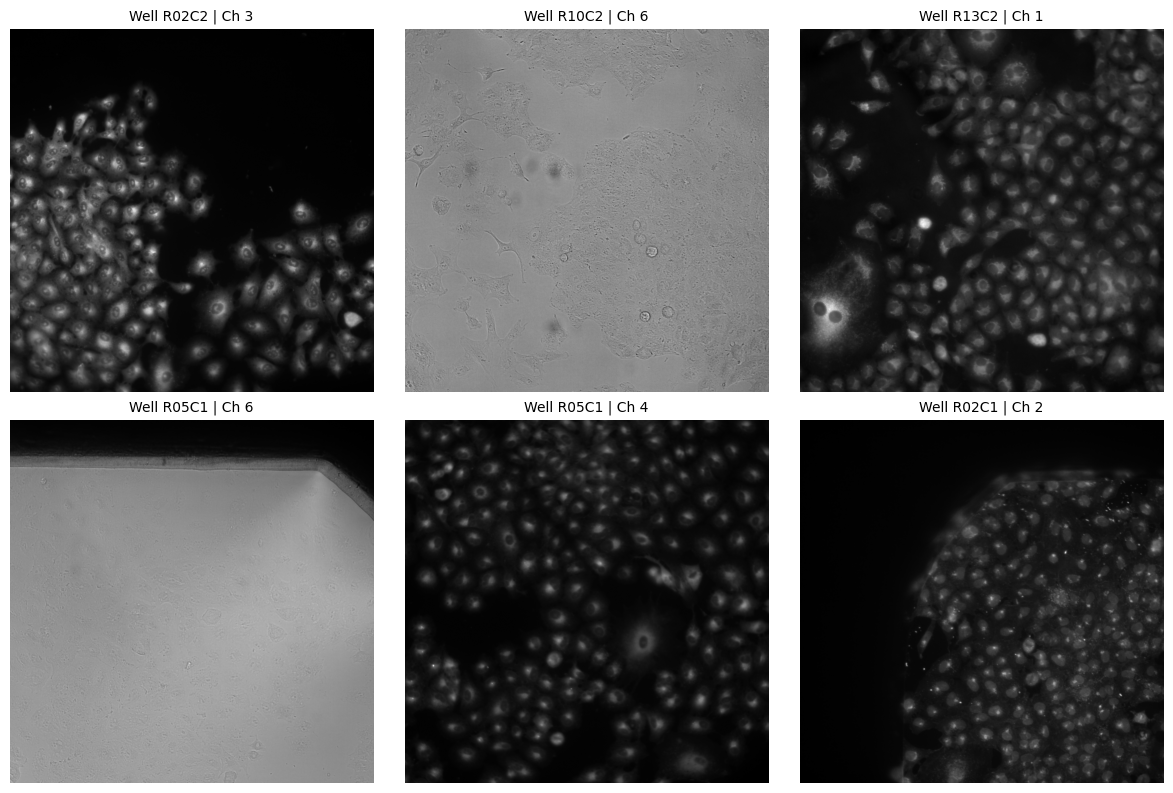

In [4]:
# Visualize

def display_images_from_list(file_paths, max_display=9):
    """
    Reads, normalizes, and displays a list of single-channel 16-bit TIFF images 
    in a grid format using matplotlib subplots.
    """
    files_to_display = file_paths[:max_display]
    num_images = len(files_to_display)
    
    if num_images == 0:
        print("No files to display.")
        return

    # Calculate grid size (e.g., 5 images -> 2 rows, 3 columns)
    cols = 3
    rows = math.ceil(num_images / cols)
    
    # Create the figure and subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    print(f"Displaying {num_images} images in a {rows}x{cols} grid...")

    for i, file_path in enumerate(files_to_display):
        ax = axes[i]
        filename = os.path.basename(file_path)
        
        try:
            # 1. Read the 16-bit TIFF image
            img_array = tiff.imread(file_path)

            # 2. Normalize 16-bit data (min/max scaling)
            min_val = np.min(img_array)
            max_val = np.max(img_array)
            
            if max_val > min_val:
                normalized_img = (img_array.astype(float) - min_val) / (max_val - min_val)
            else:
                normalized_img = img_array 
            
            # 3. Visualize the image in the subplot
            ax.imshow(normalized_img, cmap='gray')
            
            # Extract relevant info for title: Well and Channel
            # Example filename: r02c20f07p01-ch3..._C03.tif
            well_id = filename[0:5].upper() # r02c20 -> R02C20
            channel = filename[filename.find('ch') + 2 : filename.find('sk')] # Extracts '3' from ch3sk1
            
            ax.set_title(f"Well {well_id} | Ch {channel}", fontsize=10)
            ax.axis('off')

        except Exception as e:
            ax.set_title(f"Error loading: {filename}")
            print(f"Error loading {filename}: {e}")
            ax.axis('off')

    # Hide any unused subplots if num_images is not a multiple of cols
    for j in range(num_images, rows * cols):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
    
# Assuming 'tiff_files' contains the full list of paths from your directory scan:
if 'tiff_files' in locals() and tiff_files:
    # Display the first 6 images (2 rows, 3 columns)
    display_images_from_list(tiff_files, max_display=6)
else:
    print("Please run the first two cells (Listing files) to populate the 'tiff_files' list.")

# Embed

In [10]:
# Prepare data

data_file_path = './data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images'

site_file_groups = defaultdict(list)

for file_path in tiff_files:
    filename = os.path.basename(file_path)

    site_key = filename[:filename.find('p01')] 
    site_file_groups[site_key].append(file_path)

# Filter for groups that have exactly 5 channels (the standard CP assay)
valid_sites = {
    key: sorted(paths) for key, paths in site_file_groups.items()
}

print(f"Total valid {len(valid_sites)} multi-channel sites found.")
first_site_key = next(iter(valid_sites.keys()))
print(f"Example site files: {valid_sites[first_site_key]}")


# --- 2. Custom PyTorch Dataset ---

class PhenoImageDataset(Dataset):
    def __init__(self, valid_sites):
        # valid_sites is a dictionary {site_key: [path_c1, path_c2, ...]}
        self.site_keys = list(valid_sites.keys())
        self.site_data = valid_sites

    def __len__(self):
        return len(self.site_keys)

    def __getitem__(self, idx):
        site_key = self.site_keys[idx]
        channel_paths = self.site_data[site_key]
        
        # H, W should be standard (e.g., 1080x1080)
        
        # 1. Read and stack all 5 channels
        stacked_channels = []
        for path in channel_paths:
            img = tiff.imread(path)
            stacked_channels.append(img[np.newaxis, :, :]) # Add channel dimension (1, H, W)

        # Resulting tensor shape: (5, H, W)
        image_tensor = np.concatenate(stacked_channels, axis=0)
        
        # 2. Convert to PyTorch Tensor and Normalize
        # The MAE model expects 16-bit data to be scaled, usually to 0-1 or Z-scored.
        # We'll use simple min/max normalization per channel.
        image_tensor = torch.from_numpy(image_tensor).float()
        
        normalized_tensors = []
        for c in range(image_tensor.shape[0]):
            channel_data = image_tensor[c]
            min_val = channel_data.min()
            max_val = channel_data.max()
            if max_val > min_val:
                normalized_tensors.append((channel_data - min_val) / (max_val - min_val))
            else:
                normalized_tensors.append(channel_data)
        
        final_tensor = torch.stack(normalized_tensors)
        
        return final_tensor, site_key

# Instantiate the dataset and DataLoader
pheno_dataset = PhenoImageDataset(valid_sites)
pheno_dataloader = DataLoader(pheno_dataset, batch_size=4, shuffle=False)

print(f"Dataset ready. Example tensor shape: {pheno_dataset[0][0].shape}")

Total valid 1536 multi-channel sites found.
Example site files: ['./data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07p01-ch1sk1fk1fl1.tiff', './data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07p01-ch2sk1fk1fl1.tiff', './data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07p01-ch3sk1fk1fl1.tiff', './data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07p01-ch4sk1fk1fl1.tiff', './data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07p01-ch5sk1fk1fl1.tiff', './data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07p01-ch6sk1fk1fl1.tiff', './data/img/2020_11_18_CPJUMP1_TimepointDay1/images/BR00117006__2020-11-03T19_45_39-Measurement1/Images/r02c20f07

In [14]:
# Embedding

EMBEDDING_DIM = 512 


class MAEModel(torch.nn.Module):
    """
    NOTE: YOU MUST REPLACE THIS CLASS with the actual recursionpharma/OpenPhenom MAEModel
    and ensure you have the model weights downloaded to the './' directory.
    """
    def __init__(self, in_channels=5, output_dim=EMBEDDING_DIM):
        super().__init__()
        print("\n--- WARNING: Using DUMMY MAE ENCODER ---")
        
        # Simulate ViT encoder structure
        self.backbone = torch.nn.Conv2d(in_channels, output_dim, kernel_size=16, stride=16) 
        self.global_pool = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = torch.nn.Linear(output_dim, output_dim)

    @classmethod
    def from_pretrained(cls, model_dir):
        # In the real scenario, this loads weights and config.
        # Here, we just initialize the dummy class.
        return cls()

    def forward(self, x):
        # Ensure the input is ready: (B, C, H, W)
        x = self.backbone(x)
        x = self.global_pool(x)
        # Flatten and output
        x = x.flatten(1)
        x = self.output_layer(x)
        return x

# --- Embedding Generation Loop ---

# Configuration from previous thought/cell


huggingface_phenombeta_model_dir = "./" 
huggingface_model = MAEModel.from_pretrained(huggingface_phenombeta_model_dir)
huggingface_model = huggingface_model.eval()

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
huggingface_model.to(device)

all_embeddings = []
all_site_keys = []

with torch.no_grad():
    for images, site_keys in tqdm(pheno_dataloader, desc="Generating Embeddings"):
        
        # 1. Send data to device
        images = images.to(device)
        
        # 2. Get embeddings from the model
        embeddings = huggingface_model(images)
        
        # 3. Store results
        all_embeddings.append(embeddings.cpu().numpy())
        all_site_keys.extend(site_keys)

# Concatenate all batch results
final_embeddings = np.concatenate(all_embeddings, axis=0)

print(f"\n✅ Embedding generation complete!")
print(f"Total embeddings generated: {final_embeddings.shape[0]}")
print(f"Final embedding shape (N, D): {final_embeddings.shape}")


--- WARNING: Using DUMMY MAE ENCODER ---


Generating Embeddings:   0%|          | 0/384 [00:00<?, ?it/s]


RuntimeError: Given groups=1, weight of size [512, 5, 16, 16], expected input[4, 8, 1080, 1080] to have 5 channels, but got 8 channels instead